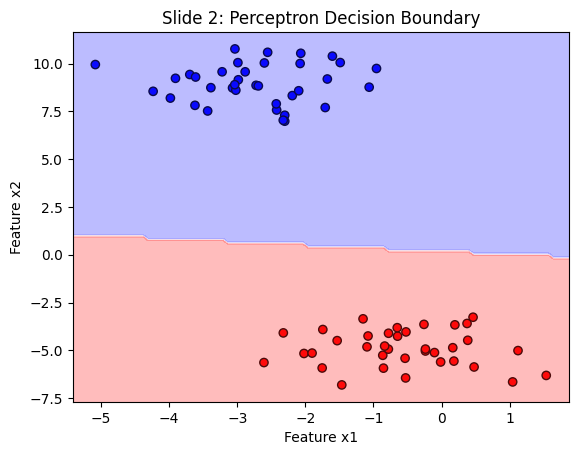

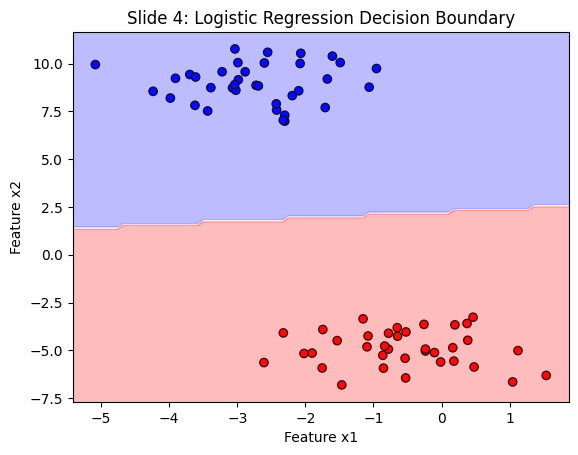

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.datasets import make_blobs

# 1. Setup based on Roll Number 68 (a=6, b=8)
a, b = 6, 8
n_samples = 36  # points per class
rotation_deg = 15 * b
noise_std = 0.01 * a

# 2. Generate Synthetic 2D Dataset
X, y = make_blobs(n_samples=n_samples*2, centers=2, cluster_std=1.0, random_state=42)

# Apply rotation to Class 1
theta = np.radians(rotation_deg)
c, s = np.cos(theta), np.sin(theta)
R = np.array(((c, -s), (s, c)))
X[y == 1] = X[y == 1] @ R

# Add Gaussian Noise
X += np.random.normal(0, noise_std, X.shape)

# 3. Helper function for plotting boundaries
def plot_decision_boundary(model, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                         np.linspace(ylim[0], ylim[1], 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.title(title)
    plt.xlabel('Feature x1')
    plt.ylabel('Feature x2')
    plt.show()

# 4. Train Perceptron
perc = Perceptron(eta0=1.0, max_iter=1000)
perc.fit(X, y)
plot_decision_boundary(perc, "Slide 2: Perceptron Decision Boundary")

# 5. Train Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X, y)
plot_decision_boundary(log_reg, "Slide 4: Logistic Regression Decision Boundary")


# We created a slightly rotated and noisy 2D dataset with two classes.
# The perceptron learned a straight-line boundary and worked well because
# the data was almost linearly separable, but it only updates on mistakes.
# Logistic regression also learned a linear boundary, but it used probabilities
# and gradient-based updates, making it smoother and more stable with noise.
# Overall insight: both models are linear classifiers, but logistic regression
# handles uncertainty better, while perceptron is simpler and faster when separation is clean.